In [1]:
from sbcbinaryformat import Streamer, Writer
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.patches import Rectangle
from matplotlib.patches import ConnectionPatch
from skimage.draw import circle_perimeter
from skimage.draw import disk
from GetEvent import GetEvent
import diplib as dip

DIPlib -- a quantitative image analysis library
Version 3.6.0 (Oct 23 2025)
For more information see https://diplib.org


In [2]:
TEST_RUN='/exp/e961/data/SBC-25-unpacked/20260219_4'
TEST_EVT = 21 

ev = GetEvent(TEST_RUN, TEST_EVT, strictMode=False)

/exp/e961/app/users/alkucich/LAr10Ana/GetEvent.py:132: UserWarning: No scintillation file present in the run directory. Data will not be available in the returned dictionary.
  warnings.warn("No scintillation file present in the run directory. Data will not be available in the returned dictionary.")


In [3]:
#get details about the specific bubble image we want
frame = 27 
cam = 3
y_cent = 542 
x_cent = 400 
ybox_low = x_cent+25
ybox_high = x_cent-25
xbox_low = y_cent-25
xbox_high = y_cent+25

#get images
refIm = np.average(ev['cam'][f'c{cam}']['frame0'],axis=2)
prev2Im = np.average(ev['cam'][f'c{cam}'][f'frame{frame-2}'],axis=2)
prevIm = np.average(ev['cam'][f'c{cam}'][f'frame{frame-1}'],axis=2)
Im = np.average(ev['cam'][f'c{cam}'][f'frame{frame}'],axis=2)
nextIm = np.average(ev['cam'][f'c{cam}'][f'frame{frame+1}'],axis=2)
imShape = Im.shape

#params and masks used in bubble finder 
noise_thresh = 10
if cam==1:
    circy, circx = disk((375, 595), 300, shape=imShape)
    coord_mask = 1.9*circx-1200<circy
    mask_circx = circx[coord_mask]
    mask_circy = circy[coord_mask]
elif cam==2:
    mask_circy, mask_circx = disk((420, 670), 300, shape=imShape)
elif cam==3:
    mask_circy, mask_circx = disk((440, 690), 300, shape=imShape)

#get diffs the same way the bubble finder does: take raw diff, mask out walls, get rid of single pixels
preMask_diff = abs(Im-prevIm)
preMask_diff[preMask_diff<noise_thresh] = 0
diff = np.zeros((imShape[0],imShape[1]))
diff[mask_circy,mask_circx] = preMask_diff[mask_circy,mask_circx]
diff-=dip.GetSinglePixels(diff > 0)

preMask_prevDiff = abs(prevIm-prev2Im)
preMask_prevDiff[preMask_prevDiff<noise_thresh] = 0
prevDiff = np.zeros((imShape[0],imShape[1]))
prevDiff[mask_circy,mask_circx] = preMask_prevDiff[mask_circy,mask_circx]
prevDiff-=dip.GetSinglePixels(prevDiff > 0)

preMask_nextDiff = abs(nextIm-Im)
preMask_nextDiff[preMask_nextDiff<noise_thresh] = 0
nextDiff = np.zeros((imShape[0],imShape[1]))
nextDiff[mask_circy,mask_circx] = preMask_nextDiff[mask_circy,mask_circx]
nextDiff-=dip.GetSinglePixels(nextDiff > 0)

#load bubble pixel coordinates and radius from bubble finder/ Hough transform output
bf_file = '/exp/e961/data/SBC-25-recon/dev-output/20260219_4/bubble.sbc'
bf_output = Streamer(bf_file).to_dict()

evt_mask = bf_output['ev']==TEST_EVT
this_frame_mask = bf_output['frame']==frame
next_frame_mask = bf_output['frame']==frame+1
cam_mask = bf_output['cam']==cam

pos = bf_output['pos'][evt_mask & this_frame_mask & cam_mask][0]
rad = bf_output['radius'][evt_mask & this_frame_mask & cam_mask][0]

nextPos = bf_output['pos'][evt_mask & next_frame_mask & cam_mask][0]
nextRad = bf_output['radius'][evt_mask & next_frame_mask & cam_mask][0]

In [4]:
#frames saved out of order indicate diff wrt frame0 was used for pre t0 frames;
#check to see if prevdiff or refdiff used
evt_mask = bf_output['ev']==TEST_EVT
cam_mask = bf_output['cam']==cam
bf_output['frame'][evt_mask & cam_mask]

array([27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38])

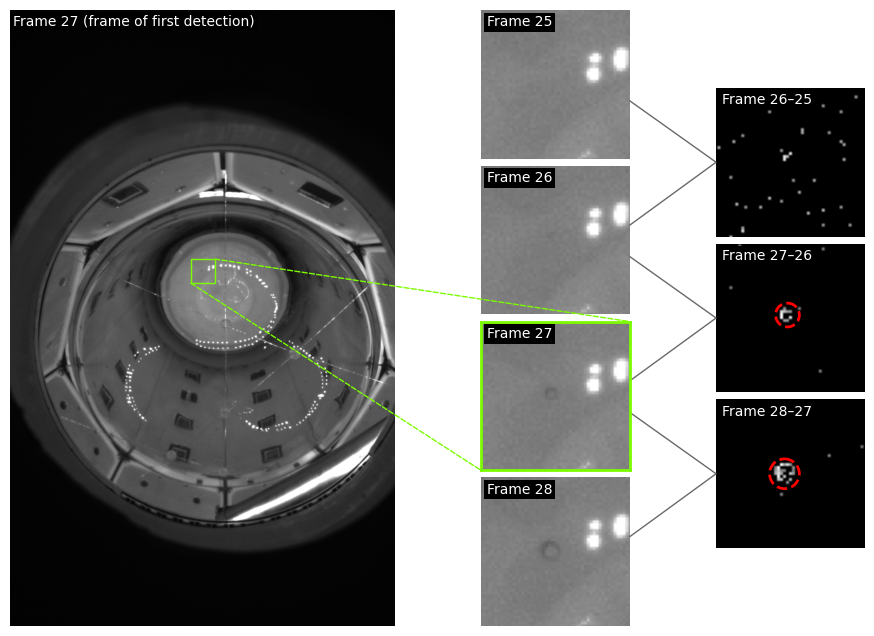

In [5]:
#set up mosaic and figure, axes
mos = [['l','l','l','l','c1','c1','.','.'],
       ['l','l','l','l','c1','c1','r1','r1'],
       ['l','l','l','l','c2','c2','r1','r1'],
       ['l','l','l','l','c2','c2','r2','r2'],
       ['l','l','l','l','c3','c3','r2','r2'],
       ['l','l','l','l','c3','c3','r3','r3'],
       ['l','l','l','l','c4','c4','r3','r3'],
       ['l','l','l','l','c4','c4','.','.']]

fig, ax = plt.subplot_mosaic(mos)
zoomCol = 'lawngreen' #'mediumturquoise' #'darkorange'
diffCol = 'dimgray'
fontfam = 'sans-serif'

#left column, full chamber image of bub t0 frame
ax['l'].imshow(Im.T, cmap='gray')
box = Rectangle((ybox_high,xbox_high), width = xbox_high-xbox_low, height = ybox_high-ybox_low, color=zoomCol, fill=False, lw=1) 
ax['l'].add_patch(box)
ax['l'].annotate(f'Frame {frame} (frame of first detection)', xy=(5,32), c='w', fontfamily=fontfam, bbox=dict(facecolor='0', edgecolor='none', pad=2))
#ax['l'].set_xlim(175,1150) #cam3
ax['l'].axis('off')

#center column, zoomed in raw images
ax['c1'].imshow(prev2Im.T, cmap='gray')
ax['c1'].set_xlim(ybox_high,ybox_low)
ax['c1'].set_ylim(xbox_high,xbox_low)
ax['c1'].annotate(f'Frame {frame-2}', xy=(ybox_high+2,xbox_low+5.5), c='w', fontfamily=fontfam, bbox=dict(facecolor='0', edgecolor='none', pad=2))
ax['c1'].axis('off')

ax['c2'].imshow(prevIm.T, cmap='gray')
ax['c2'].set_xlim(ybox_high,ybox_low)
ax['c2'].set_ylim(xbox_high,xbox_low)
ax['c2'].annotate(f'Frame {frame-1}', xy=(ybox_high+2,xbox_low+5.5), c='w', fontfamily=fontfam, bbox=dict(facecolor='0', edgecolor='none', pad=2))
ax['c2'].axis('off')

ax['c3'].imshow(Im.T, cmap='gray')
ax['c3'].set_xlim(ybox_high,ybox_low)
ax['c3'].set_ylim(xbox_high,xbox_low)
ax['c3'].annotate(f'Frame {frame}', xy=(ybox_high+2,xbox_low+5.5), c='w', fontfamily=fontfam, bbox=dict(facecolor='0', edgecolor='none', pad=2))
ax['c3'].get_xaxis().set_visible(False)
ax['c3'].get_yaxis().set_visible(False)

ax['c3'].spines['top'].set_color(zoomCol)
ax['c3'].spines['top'].set_linewidth(2)
ax['c3'].spines['bottom'].set_color(zoomCol)
ax['c3'].spines['bottom'].set_linewidth(2)
ax['c3'].spines['left'].set_color(zoomCol)
ax['c3'].spines['left'].set_linewidth(2)
ax['c3'].spines['right'].set_color(zoomCol)
ax['c3'].spines['right'].set_linewidth(2)

#create lines to complete zoom-in
zoom_line1 = ConnectionPatch(xyA=(ybox_high, xbox_high), xyB=(ybox_high, xbox_high), coordsA=ax['l'].transData, coordsB =ax['c3'].transData, color=zoomCol, lw=1, linestyle='--')
zoom_line2 = ConnectionPatch(xyA=(ybox_low, xbox_low), xyB=(ybox_low, xbox_low), coordsA=ax['l'].transData, coordsB =ax['c3'].transData, color=zoomCol, lw=1, linestyle='--')
ax['c3'].add_patch(zoom_line1)
ax['c3'].add_patch(zoom_line2)

ax['c4'].imshow(nextIm.T, cmap='gray')
ax['c4'].set_xlim(ybox_high,ybox_low)
ax['c4'].set_ylim(xbox_high,xbox_low)
ax['c4'].annotate(f'Frame {frame+1}', xy=(ybox_high+2,xbox_low+5.5), c='w', fontfamily=fontfam, bbox=dict(facecolor='0', edgecolor='none', pad=2))
ax['c4'].axis('off')

#right column, diffs 
ax['r1'].imshow(prevDiff.T, cmap='gray')
ax['r1'].set_xlim(ybox_high,ybox_low)
ax['r1'].set_ylim(xbox_high,xbox_low)
ax['r1'].annotate(f'Frame {frame-1}–{frame-2}', xy=(ybox_high+2,xbox_low+5.5), c='w', fontfamily=fontfam, bbox=dict(facecolor='0', edgecolor='none', pad=2))
ax['r1'].axis('off')

ax['r2'].imshow(diff.T, cmap='gray')
#xhair = Circle((int(pos[1]),int(pos[0])), int(rad), color='r', fill=False, linestyle='--', lw=2) #get circle over bubble
xhair = Circle((int(pos[1]),int(pos[0])), int(rad)+2, color='r', fill=False, linestyle='--', lw=2) #get circle over bubble
ax['r2'].add_patch(xhair)
ax['r2'].set_xlim(ybox_high,ybox_low)
ax['r2'].set_ylim(xbox_high,xbox_low)
ax['r2'].annotate(f'Frame {frame}–{frame-1}', xy=(ybox_high+2,xbox_low+5.5), c='w', fontfamily=fontfam, bbox=dict(facecolor='0', edgecolor='none', pad=2))
ax['r2'].axis('off')

ax['r3'].imshow(nextDiff.T, cmap='gray')
#next_xhair = Circle((int(nextPos[1]),int(nextPos[0])), int(nextRad), color='r', fill=False, linestyle='--', lw=2) #get circle over bubble
next_xhair = Circle((int(nextPos[1]),int(nextPos[0])), int(nextRad)+2, color='r', fill=False, linestyle='--', lw=2)
ax['r3'].add_patch(next_xhair)
ax['r3'].set_xlim(ybox_high,ybox_low)
ax['r3'].set_ylim(xbox_high,xbox_low)
ax['r3'].annotate(f'Frame {frame+1}–{frame}', xy=(ybox_high+2,xbox_low+5.5), c='w', fontfamily=fontfam, bbox=dict(facecolor='0', edgecolor='none', pad=2))
ax['r3'].axis('off')

#create lines showing relationship between 2nd and 3rd columns
diff_line1 = ConnectionPatch(xyA=(ybox_low, (xbox_high+xbox_low)/2+5.5), xyB=(ybox_high, (xbox_high+xbox_low)/2), coordsA=ax['c1'].transData, coordsB =ax['r1'].transData, color=diffCol, lw=1, linestyle='-')
diff_line2 = ConnectionPatch(xyA=(ybox_high, (xbox_high+xbox_low)/2), xyB=(ybox_low, (xbox_high+xbox_low)/2-5), coordsA=ax['r1'].transData, coordsB =ax['c2'].transData, color=diffCol, lw=1, linestyle='-')
ax['c1'].add_patch(diff_line1)
ax['c2'].add_patch(diff_line2)
diff_line3 = ConnectionPatch(xyA=(ybox_low, (xbox_high+xbox_low)/2+5.5), xyB=(ybox_high, (xbox_high+xbox_low)/2), coordsA=ax['c2'].transData, coordsB =ax['r2'].transData, color=diffCol, lw=1, linestyle='-')
diff_line4 = ConnectionPatch(xyA=(ybox_high, (xbox_high+xbox_low)/2), xyB=(ybox_low, (xbox_high+xbox_low)/2-5), coordsA=ax['r2'].transData, coordsB =ax['c3'].transData, color=diffCol, lw=1, linestyle='-')
ax['c2'].add_patch(diff_line3)
ax['c3'].add_patch(diff_line4)
diff_line5 = ConnectionPatch(xyA=(ybox_low, (xbox_high+xbox_low)/2+5.5), xyB=(ybox_high, (xbox_high+xbox_low)/2), coordsA=ax['c3'].transData, coordsB =ax['r3'].transData, color=diffCol, lw=1, linestyle='-')
diff_line6 = ConnectionPatch(xyA=(ybox_high, (xbox_high+xbox_low)/2), xyB=(ybox_low, (xbox_high+xbox_low)/2-5), coordsA=ax['r3'].transData, coordsB =ax['c4'].transData, color=diffCol, lw=1, linestyle='-')
ax['c3'].add_patch(diff_line5)
ax['c4'].add_patch(diff_line6)

fig.set_figwidth(12)
fig.set_figheight(8)
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.savefig('IIIB1.png')
plt.show()

In [6]:
rad, nextRad, pos, nextPos

(np.float64(2.0), np.float64(3.0), array([541, 399]), array([542, 398]))

In [7]:
reco_file = '/exp/e961/data/SBC-25-recon/dev-output/20260219_4/reco.sbc'
reco = Streamer(reco_file).to_dict()

In [23]:
reco['coords_3D'][reco['ev']==TEST_EVT][:,2][28]

np.float64(-19.07658275673842)